### Imports

In [414]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    precision_recall_curve,
)

from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.neural_network import MLPClassifier

from imblearn.over_sampling import SMOTE

In [415]:
def load_data(path: str | Path, **kwargs) -> pd.DataFrame:
    """
    Load CSV or Excel files.

    Parameters
    ----------
    path : str or Path
        Path to the dataset.

    Returns
    -------
    pd.DataFrame
    """
    path = Path(path)

    suffix = path.suffix.lower()

    if suffix == ".csv":
        try:
            return pd.read_csv(path, **kwargs)
        except UnicodeDecodeError:
            return pd.read_csv(path, encoding="latin1", **kwargs)

    elif suffix in [".xlsx", ".xls"]:
        return pd.read_excel(path, **kwargs)

    else:
        raise ValueError(f"Unsupported file format: {suffix}")


def dataset_overview(df: pd.DataFrame) -> None:
    """Print a quick overview of a dataframe."""

    print("=" * 60)
    print(f"Rows:    {df.shape[0]:,}")
    print(f"Columns: {df.shape[1]}")
    print()

    print(df.dtypes)

    print("\nMissing values:")
    print(df.isna().sum().sort_values(ascending=False))

    print("\nMemory usage:")
    print(f"{df.memory_usage(deep=True).sum()/1024**2:.2f} MB")

In [416]:
df = load_data("train.csv")
dataset_overview(df)

Rows:    13,956
Columns: 15

Company ID                     int64
Province                         str
Sales Revenue                float64
Employees                      int64
Net income                   float64
Operating Income             float64
Maximum deductible amount    float64
Total financial expenses     float64
Tax shield                   float64
Operating cash flow          float64
Current taxes                float64
Alert Index                      str
Ateco                          int64
sector                           str
Financial distress              bool
dtype: object

Missing values:
sector                       1
Province                     0
Company ID                   0
Employees                    0
Net income                   0
Operating Income             0
Sales Revenue                0
Maximum deductible amount    0
Total financial expenses     0
Operating cash flow          0
Tax shield                   0
Current taxes                0
Alert Index  

### Fitting and testing

In [417]:
def prepare_data(df, target, drop_cols=("Company ID",)):
    df_copy = df.copy()
    df_copy = df_copy.dropna()
    df_copy["Total financial expenses"] = df_copy["Total financial expenses"].clip(lower=0)
    df_copy["Ateco"] = df_copy["Ateco"].astype(str)

    excellent_value = df_copy.loc[df_copy["Alert Index"].apply(lambda x: not str(x).replace('.','',1).replace('-','',1).isdigit()), "Alert Index"]  # sanity check, optional

    alert_numeric = pd.to_numeric(df_copy["Alert Index"], errors="coerce")
    excellent_mask = df_copy["Alert Index"] == "EXCELLENT"

    fill_value = alert_numeric.quantile(0.90)  # ~272, based on your distribution above
    df_copy["Alert Index"] = alert_numeric.where(~excellent_mask, fill_value)

    X = df_copy.drop(columns=[target, *drop_cols])
    y = df_copy[target]

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.01, random_state=42, stratify=y, shuffle=True)

    num_cols = X.select_dtypes(include="number").columns
    cat_cols = X.select_dtypes(exclude="number").columns

    return X_train, X_test, y_train, y_test, num_cols, cat_cols


def train_model(X_train, y_train, num_cols, cat_cols, classifier):
    preprocessor = ColumnTransformer(
        transformers=[
            (
                "num",
                Pipeline([
                    ("imputer", SimpleImputer(strategy="median")),
                ]),
                num_cols,
            ),
            (
                "cat",
                Pipeline([
                    ("imputer", SimpleImputer(strategy="most_frequent")),
                    ("encoder", OneHotEncoder(handle_unknown="ignore", min_frequency=10, sparse_output=False))
                ]),
                cat_cols,
            ),
        ]
    )

    model = Pipeline([
        ("preprocessing", preprocessor),
        ("classifier", classifier)
    ])

    model.fit(X_train, y_train)

    return model

In [418]:
target = "Financial distress" # name of the target column in dataset
X_train, X_val, y_train, y_val, num_cols, cat_cols = prepare_data(df, target)

In [419]:
model = train_model(X_train, y_train, num_cols, cat_cols, RandomForestClassifier(
    n_estimators=300,        # more trees = more stable predictions, cheap on this data size
    max_depth=5,            # caps overfitting; unconstrained trees will memorize on 14k rows
    min_samples_leaf=5,      # prevents leaves fit to single companies/outliers
    max_features="sqrt",     # standard for classification, works fine with your one-hot columns
    class_weight={False: 1, True: 4}, # addresses the 89/11 imbalance without resampling
    random_state=42,
    n_jobs=-1,               # trains faster, all cores
))

In [420]:
y_proba = model.predict_proba(X_val)[:, 1]

threshold = 0.5  # lower threshold = flag more companies as distressed = higher recall, lower precision
y_pred = (y_proba >= threshold).astype(bool)

In [421]:
print(f"Accuracy: {accuracy_score(y_val, y_pred):.3f}\n")
precision, recall, thresholds = precision_recall_curve(y_val, y_proba)
idx = np.argmin(np.abs(thresholds - threshold))
print(f"Precision at threshold {threshold}: {precision[idx]:.3f}")
print(f"Recall at threshold {threshold}: {recall[idx]:.3f}\n")

print("Classification report")
print(classification_report(y_val, y_pred))

print("Confusion matrix")
print(confusion_matrix(y_val, y_pred))

Accuracy: 0.907

Precision at threshold 0.5: 0.600
Recall at threshold 0.5: 0.400

Classification report
              precision    recall  f1-score   support

       False       0.93      0.97      0.95       125
        True       0.60      0.40      0.48        15

    accuracy                           0.91       140
   macro avg       0.77      0.68      0.71       140
weighted avg       0.90      0.91      0.90       140

Confusion matrix
[[121   4]
 [  9   6]]


In [422]:
# produce csv with Company ID and pred_class columns for test set using y_pred, pred_class must be either TRUE or FALSE
submission_df = pd.DataFrame({
    "Company ID": df.loc[X_val.index, "Company ID"],
    "pred_class": y_pred.astype(bool)
})

submission_df.to_csv("predictions.csv", index=False)

C:\Users\Teo\AppData\Local\Temp\ipykernel_19840\1628899524.py:19: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


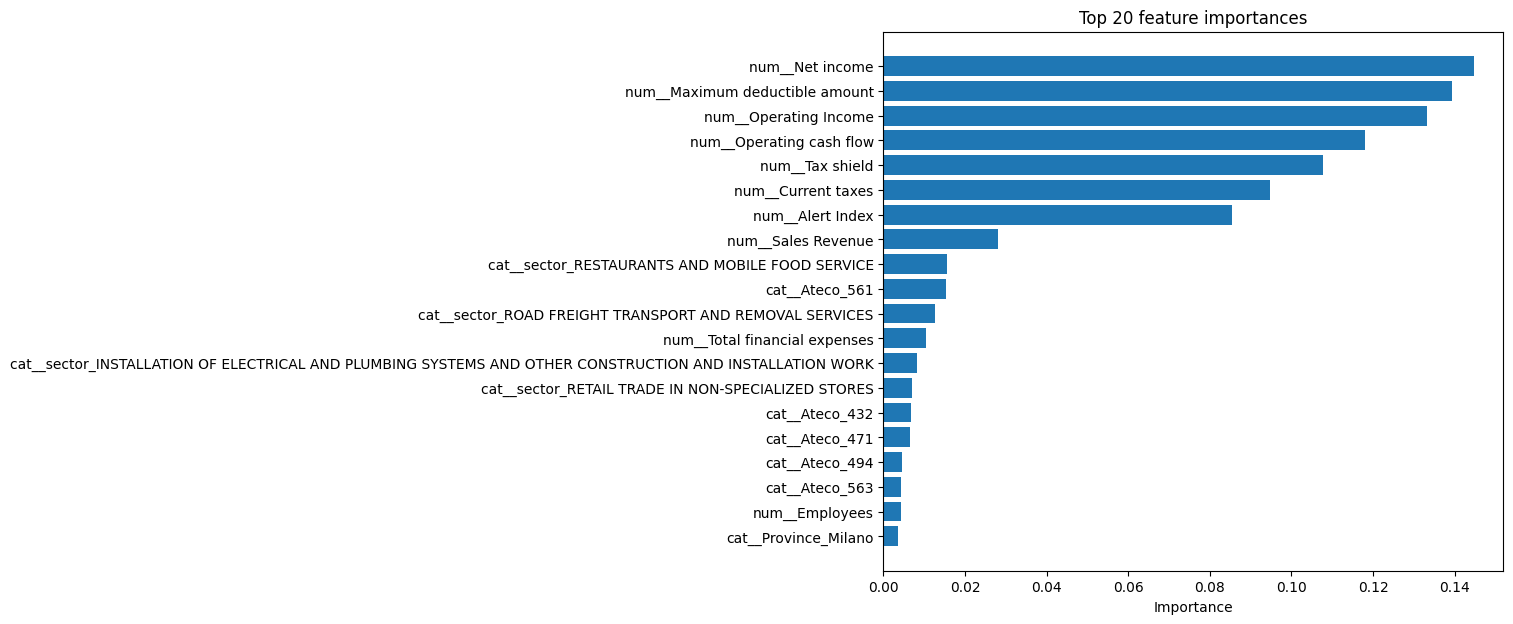

                                              feature  importance
0                                     num__Net income    0.144717
1                      num__Maximum deductible amount    0.139324
2                               num__Operating Income    0.133158
3                            num__Operating cash flow    0.118090
4                                     num__Tax shield    0.107603
5                                  num__Current taxes    0.094849
6                                    num__Alert Index    0.085322
7                                  num__Sales Revenue    0.028080
8     cat__sector_RESTAURANTS AND MOBILE FOOD SERVICE    0.015511
9                                      cat__Ateco_561    0.015440
10  cat__sector_ROAD FREIGHT TRANSPORT AND REMOVAL...    0.012666
11                      num__Total financial expenses    0.010394
12  cat__sector_INSTALLATION OF ELECTRICAL AND PLU...    0.008113
13  cat__sector_RETAIL TRADE IN NON-SPECIALIZED ST...    0.006917
14        

In [423]:
def plot_feature_importances(model, top_n=20):
    """Plot and rank feature importances from a fitted pipeline."""

    feature_names = model.named_steps["preprocessing"].get_feature_names_out()
    importances = model.named_steps["classifier"].feature_importances_

    importance_df = (
        pd.DataFrame({"feature": feature_names, "importance": importances})
        .sort_values("importance", ascending=False)
        .reset_index(drop=True)
    )

    top = importance_df.head(top_n)

    plt.figure(figsize=(8, top_n * 0.35))
    plt.barh(top["feature"][::-1], top["importance"][::-1])
    plt.xlabel("Importance")
    plt.title(f"Top {top_n} feature importances")
    plt.tight_layout()
    plt.show()

    return importance_df

importance_df = plot_feature_importances(model, top_n=20)
print(importance_df.head(20))